In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df_test = pd.read_csv('test.csv')
df_train = pd.read_csv('train.csv')

In [4]:
df_train.head()

,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option,Units_Sold
0,2024-07,Oceania,Toyota,i4,Crossover,60.084153,6.025559,High Income,No,133.340719
1,2024-03,Oceania,Toyota,Leaf,Truck,67.058251,18.953440,High Income,Yes,155.244623
2,2024-05,North America,Toyota,ID.5,Crossover,84.031469,13.006385,Middle Income,No,155.790594
3,2024-02,Oceania,Tesla,Corolla EV,Truck,73.646300,3.854783,High Income,Yes,130.724024
4,2024-10,North America,BYD,Leaf,Coupe,49.498818,4.082615,High Income,No,120.654082


In [5]:
df_test.head()

,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option
0,2023-04,Oceania,Volkswagen,Model 3,SUV,45,16,Budget Conscious,No
1,2023-10,Oceania,Ford,Model 3,Sedan,89,5,Tech Enthusiast,Yes
2,2023-10,South America,Volkswagen,Atto 3,Sedan,61,4,Budget Conscious,Yes
3,2023-02,Africa,Volkswagen,Corolla EV,Crossover,100,16,Eco-Conscious,No
4,2023-10,North America,Tesla,Rio EV,Sedan,70,8,Eco-Conscious,Yes


In [6]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Date                  275 non-null    str  
 1   Region                275 non-null    str  
 2   Brand                 275 non-null    str  
 3   Model                 275 non-null    str  
 4   Vehicle_Type          275 non-null    str  
 5   Battery_Capacity_kWh  275 non-null    int64
 6   Discount_Percentage   275 non-null    int64
 7   Customer_Segment      275 non-null    str  
 8   Fast_Charging_Option  275 non-null    str  
dtypes: int64(2), str(7)
memory usage: 19.5 KB


In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  531 non-null    str    
 1   Region                531 non-null    str    
 2   Brand                 531 non-null    str    
 3   Model                 531 non-null    str    
 4   Vehicle_Type          531 non-null    str    
 5   Battery_Capacity_kWh  531 non-null    float64
 6   Discount_Percentage   531 non-null    float64
 7   Customer_Segment      531 non-null    str    
 8   Fast_Charging_Option  531 non-null    str    
 9   Units_Sold            531 non-null    float64
dtypes: float64(3), str(7)
memory usage: 41.6 KB


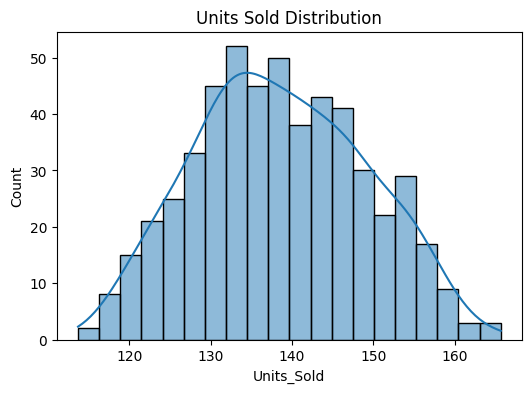

In [8]:
# Target distribution
plt.figure(figsize=(6,4))
sns.histplot(df_train["Units_Sold"], bins=20, kde=True)
plt.title("Units Sold Distribution")
plt.show()

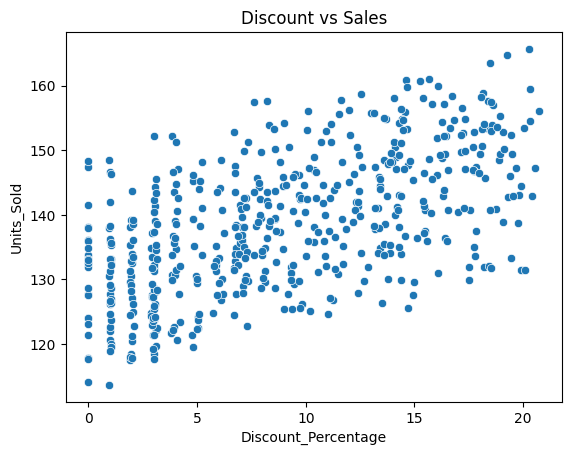

In [9]:
sns.scatterplot(x="Discount_Percentage", y="Units_Sold", data=df_train)
plt.title("Discount vs Sales")
plt.show()

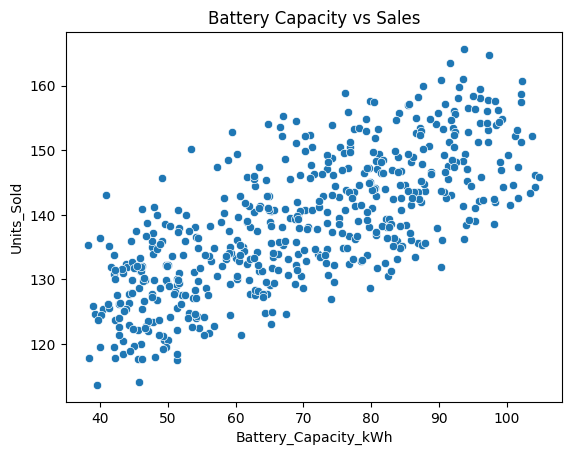

In [10]:
sns.scatterplot(x="Battery_Capacity_kWh", y="Units_Sold", data=df_train)
plt.title("Battery Capacity vs Sales")
plt.show()

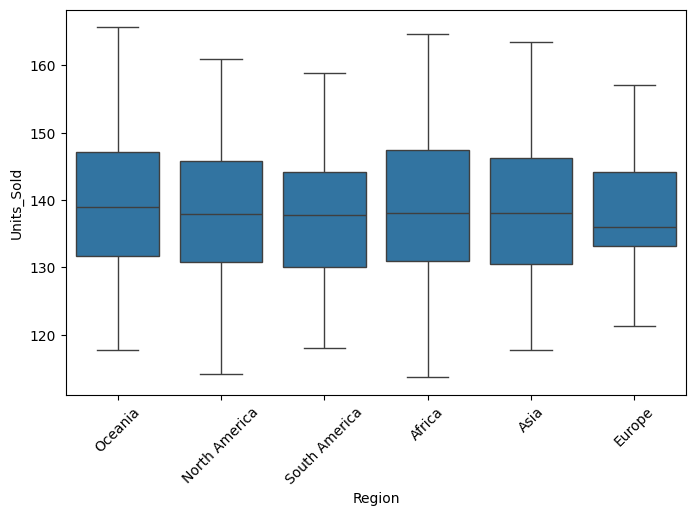

In [11]:

# Region impact
plt.figure(figsize=(8,5))
sns.boxplot(x="Region", y="Units_Sold", data=df_train)
plt.xticks(rotation=45)
plt.show()

In [12]:
def preprocess(df):
    df = df.copy()
    
    # Convert Date
    df["Date"] = pd.to_datetime(df["Date"])
    
    # Extract time features
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    
    # Drop unnecessary columns
    df = df.drop(columns=["Date", "Model"])
    
    return df

train = preprocess(df_train)
test = preprocess(df_test)

In [13]:
combined = pd.concat([df_train.drop("Units_Sold", axis=1), test])

combined = pd.get_dummies(combined, drop_first=True)


In [14]:
X = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

# print(X)
y = train["Units_Sold"]

In [15]:
X_train, X_val, y_train, y_val = train_test_split( X, y, test_size=0.2, random_state=42)

In [16]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3.882569682286578
RMSE: 4.741441398898037


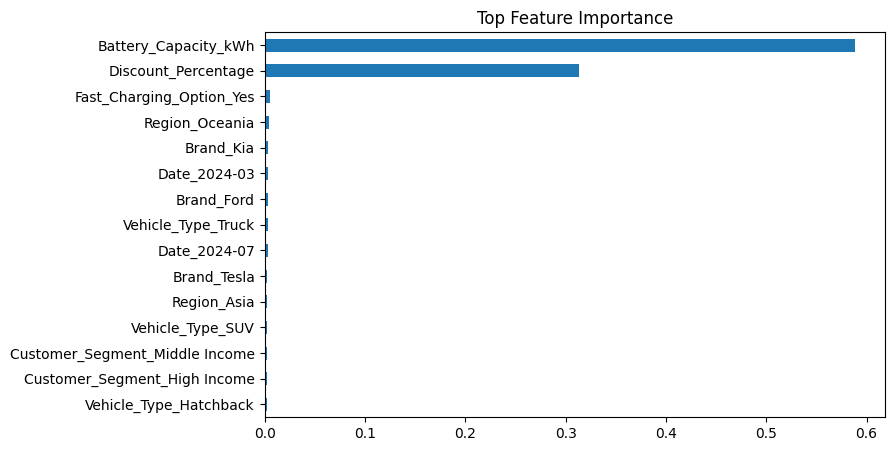

In [18]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().tail(15).plot(kind="barh", figsize=(8,5))
plt.title("Top Feature Importance")
plt.show()

In [19]:
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
test_predictions = model.predict(X_test)

test["Predicted_Units_Sold"] = test_predictions

print(test.head())

          Region       Brand Vehicle_Type  Battery_Capacity_kWh  \
0        Oceania  Volkswagen          SUV                    45   
1        Oceania        Ford        Sedan                    89   
2  South America  Volkswagen        Sedan                    61   
3         Africa  Volkswagen    Crossover                   100   
4  North America       Tesla        Sedan                    70   

   Discount_Percentage  Customer_Segment Fast_Charging_Option  Year  Month  \
0                   16  Budget Conscious                   No  2023      4   
1                    5   Tech Enthusiast                  Yes  2023     10   
2                    4  Budget Conscious                  Yes  2023     10   
3                   16     Eco-Conscious                   No  2023      2   
4                    8     Eco-Conscious                  Yes  2023     10   

   Predicted_Units_Sold  
0            133.766215  
1            144.452339  
2            132.613109  
3            157.380043 

In [21]:
import pickle
with open("ev_sales_model.pkl", "wb") as f:
    pickle.dump(model, f)


test.to_csv("ev_sales_predictions.csv", index=False)